# LINEARITY ANALYSIS

In [1]:
from src.system_discovery import SystemDiscovery, discoverNetwork
import src.constants as cn
from src.biomodels_iterator import BiomodelsIterator
from src.timecourse import Timecourse
from src.model import Model

import collections
import os
import numpy as np  # type: ignore
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
import sbmlnetwork as sb # type: ignore
import tellurium as te  # type: ignore
from typing import Optional

# Helpers

In [2]:
def checkFit(model_num: int, poly_degree=1, threshold=0.1, 
        end_time: Optional[float]=None, num_point:int=100, frac_value: float=0.0):
    print(F"Poly_degree: {poly_degree}, threshold: {threshold}")
    model = Model.makeBiomodel(model_num=model_num)
    timecourse = Timecourse(model, end_time=end_time, num_point=num_point)
    timecourse.plot()
    timecourse.timecourse_df
    return discoverNetwork(timecourse.timecourse_df, poly_degree=poly_degree, threshold=threshold)

In [3]:
def plotValueCDF(values, title: str="", xlabel: str = "ordinate", is_plot: bool = True):
    sorted = np.sort(values)
    length = len(sorted)
    yv = np.array(range(length))/length
    plt.plot(sorted, yv)
    plt.xlabel(xlabel)
    plt.ylabel("fraction")
    plt.title(title)
    if not is_plot:
        plt.close()


In [4]:
def plotCDF(evaluate_df: pd.DataFrame, column: str, title: str = "", is_plot: bool = True):
    list_strs = [v for v in evaluate_df[column] if isinstance(v, str)]
    value_arr: np.ndarray
    if len(list_strs) > 0:
        values = []
        [values.extend(eval(v)) for v in list_strs]
        value_arr = np.array(values)
    else:
        value_arr = evaluate_df[column].values  # type: ignore
    sorted_r2 = np.sort(value_arr)
    length = len(sorted_r2)
    yv = np.array(range(length))/length
    plt.plot(sorted_r2, yv)
    plt.xlabel("r-squared")
    plt.ylabel("fraction")
    plt.title(title)
    if not is_plot:
        plt.close()

#plotCDF("deg1_values", is_plot=False)
print("OK!")

OK!


# Detailed Analysis

## BioModels 8

Poly_degree: 1, threshold: 0.1

dC/dt = 0.162 * Z
dX/dt = -34.320 * C + -41260.951 * M + -31.258 * Y + 31.424 * Z
dM/dt = 0.901 * C + -3.512 * M + 0.821 * Y + -0.821 * Z
dY/dt = 0.218 * Z
dZ/dt =
R² on time derivatives per species:
  C: -380229.399384
  X: 0.025625
  M: 1.000000
  Y: -764567.031754
  Z: -35677017.469955

R² on simulated trajectories per species:
  C: -380229.399384
  X: 0.025625
  M: 1.000000
  Y: -764567.031754
  Z: -35677017.469955



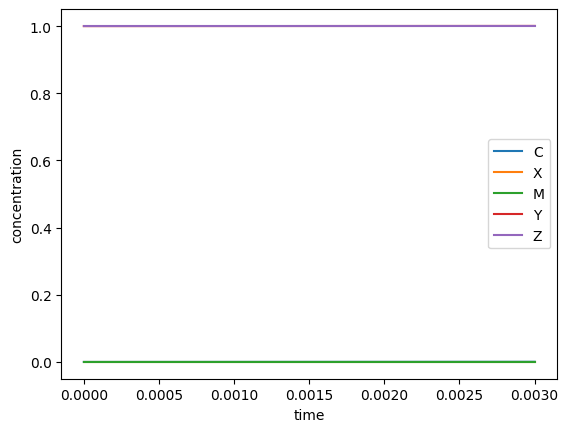

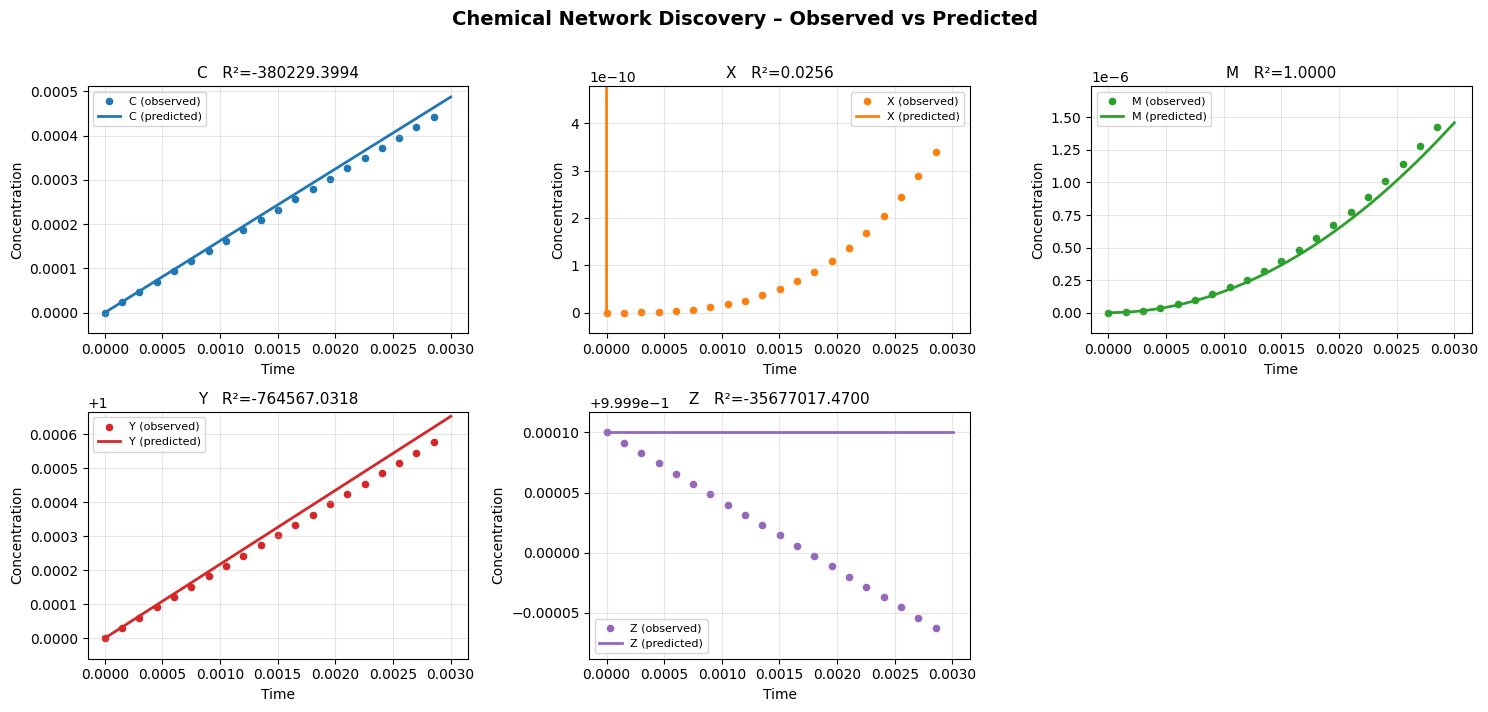

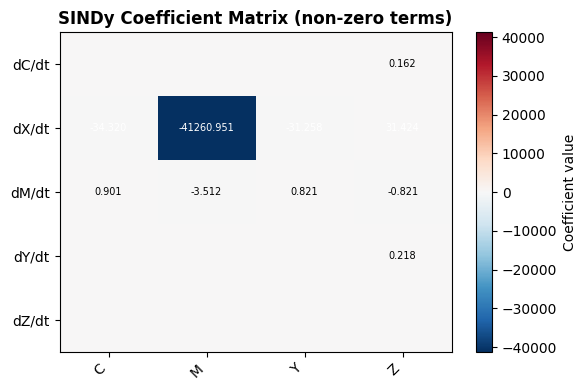

In [5]:
checkFit(8, num_point=1000)

## BioModels 206

Poly_degree: 1, threshold: 0.001

ds1/dt = 860.498 + -144.967 * s1 + -128.641 * at + -599.616 * s2 + 1657.272 * s3 + -1109.561 * na + -119.922 * s4 + 263.551 * s5 + -3250.159 * s6 + 21329.012 * s6o
dat/dt = 1959.472 + -248.139 * s1 + -276.827 * at + -1091.835 * s2 + 2894.156 * s3 + -2793.299 * na + -156.038 * s4 + 482.043 * s5 + -2530.419 * s6 + 34493.152 * s6o
ds2/dt = -808.308 + 143.953 * s1 + 128.168 * at + 589.078 * s2 + -1664.619 * s3 + 1105.913 * na + 123.988 * s4 + -262.283 * s5 + 3209.265 * s6 + -21336.057 * s6o
ds3/dt = -137.133 + -2.632 * s1 + 1.555 * at + 10.326 * s2 + -12.219 * s3 + 221.749 * na + -13.460 * s4 + 0.821 * s5 + -759.293 * s6 + 768.085 * s6o
dna/dt = -24.278 + -0.103 * s1 + 3.261 * at + -1.709 * s2 + 34.093 * s3 + 16.121 * na + -8.160 * s4 + 1.438 * s5 + -373.212 * s6 + 796.562 * s6o
ds4/dt = -181.647 + -32.427 * s1 + -11.394 * at + -95.265 * s2 + 460.677 * s3 + 346.424 * na + -92.427 * s4 + 44.844 * s5 + -2751.081 * s6 + 6789.783 * s6o
ds5/dt = 269.540 + 34.55

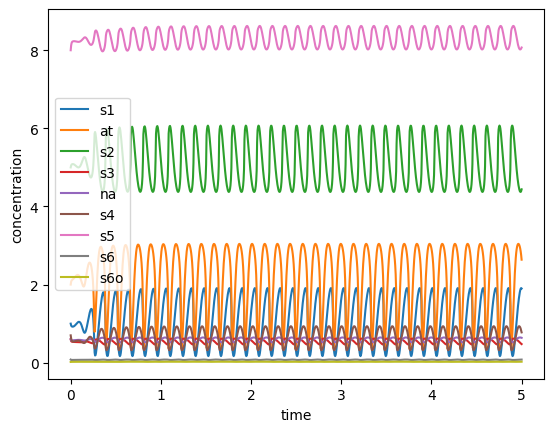

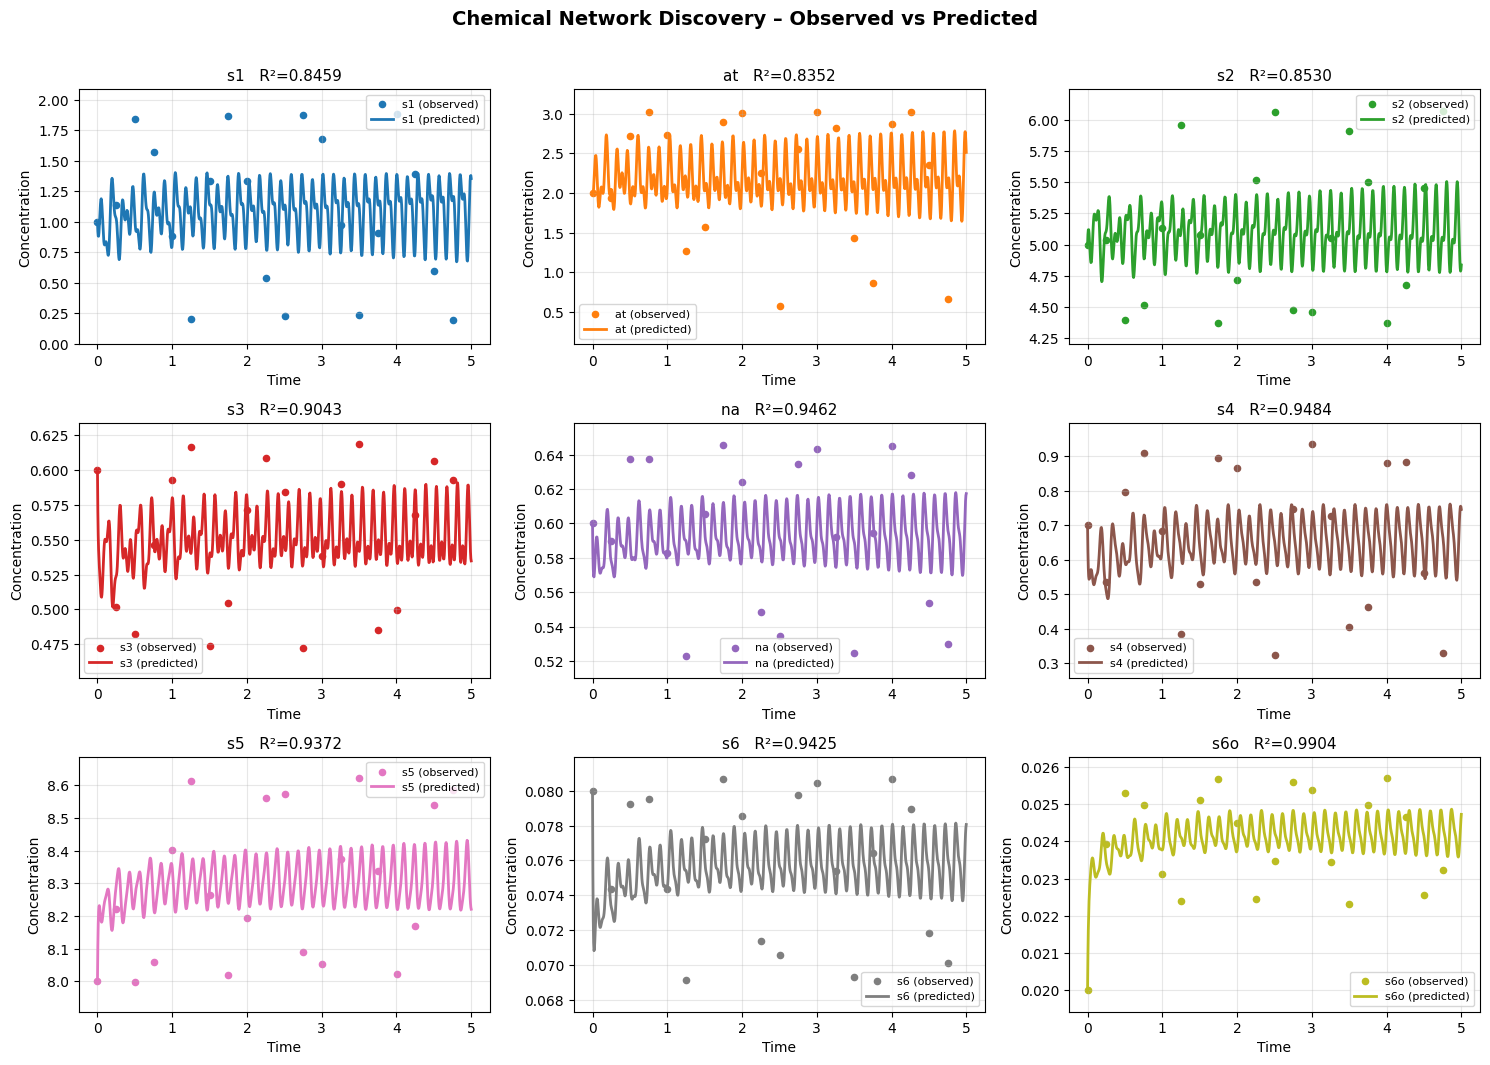

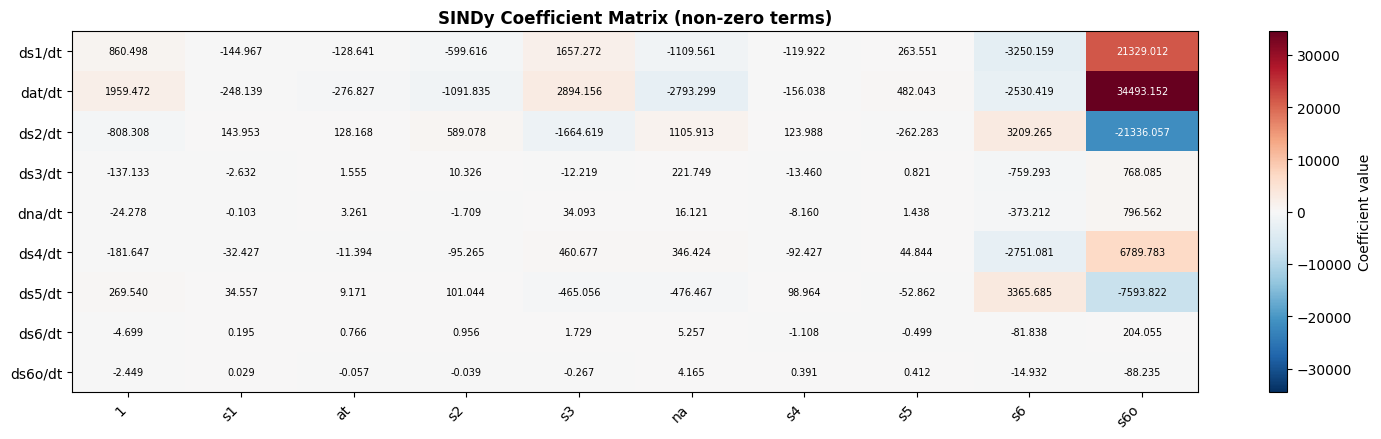

In [6]:
checkFit(206, threshold=0.001, poly_degree=1, num_point=1000, end_time=5)

## BioModels 181

Poly_degree: 1, threshold: 0.01

dT1/dt = -2.323 * T1 + 1.746 * T2 + 1.547 * T3 + -0.053 * C1 + -0.075 * C2 + 3.843 * C3
dT2/dt = -0.041 + 0.725 * T1 + -1.429 * T2 + -0.544 * T3 + 0.250 * C1 + 0.332 * C2 + -1.914 * C3
dT3/dt = 0.048 + 1.630 * T1 + -1.251 * T2 + -2.672 * T3 + 0.676 * C1 + 0.203 * C2 + -5.373 * C3
dC1/dt = -0.017 + 4.343 * T1 + -3.912 * T2 + -2.506 * T3 + 0.390 * C1 + 0.112 * C2 + -8.043 * C3
dC2/dt = 0.018 + 1.453 * T1 + -0.906 * T2 + -1.204 * T3 + 0.061 * C1 + -0.098 * C2 + -2.255 * C3
dC3/dt = 0.014 + -1.265 * T1 + 1.349 * T2 + 0.975 * T3 + -0.175 * C1 + -0.115 * C2 + 2.311 * C3
R² on time derivatives per species:
  T1: 0.999887
  T2: 1.000000
  T3: 1.000000
  C1: 1.000000
  C2: 1.000000
  C3: 0.999991

R² on simulated trajectories per species:
  T1: 0.999887
  T2: 1.000000
  T3: 1.000000
  C1: 1.000000
  C2: 1.000000
  C3: 0.999991



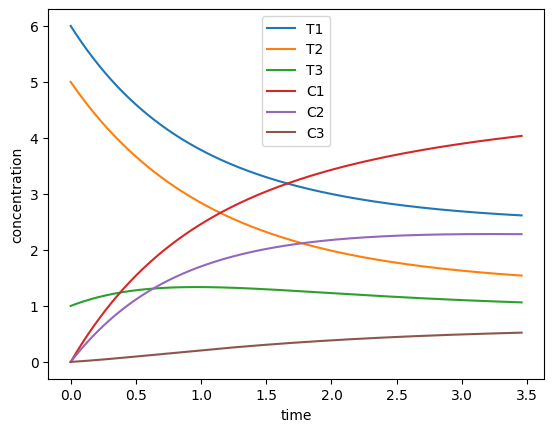

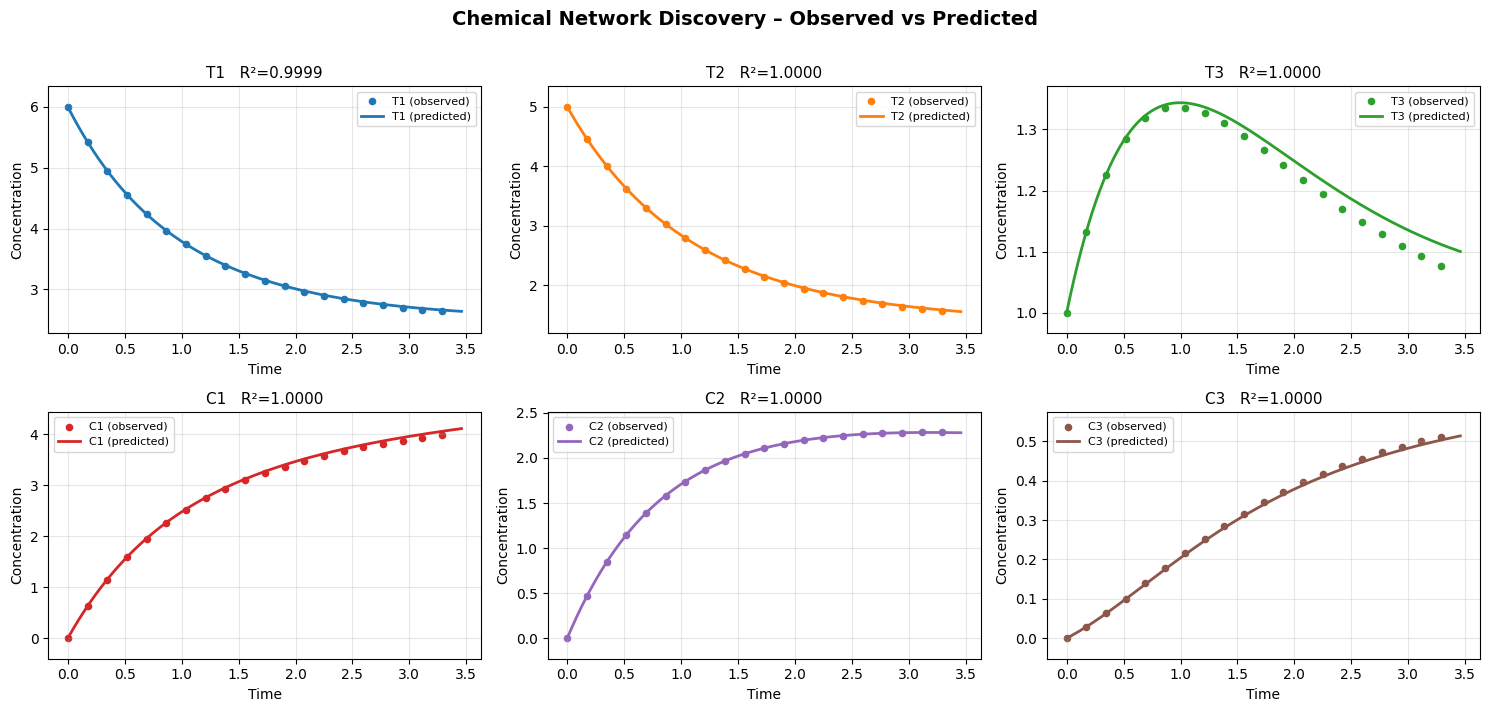

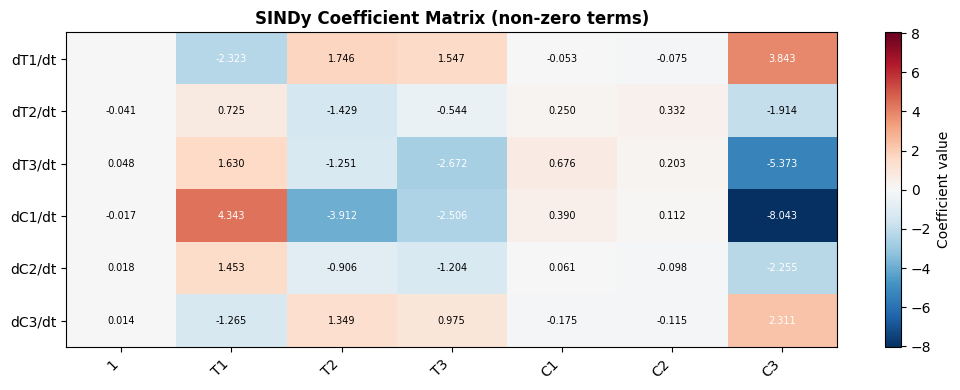

In [14]:
checkFit(181, threshold=0.01, poly_degree=1, num_point=1000)

# Analysis of fits

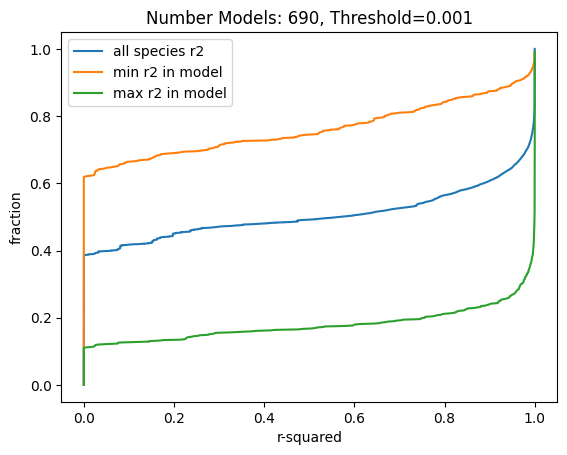

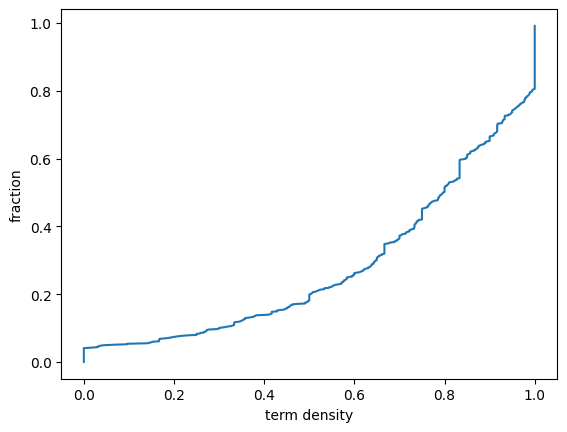

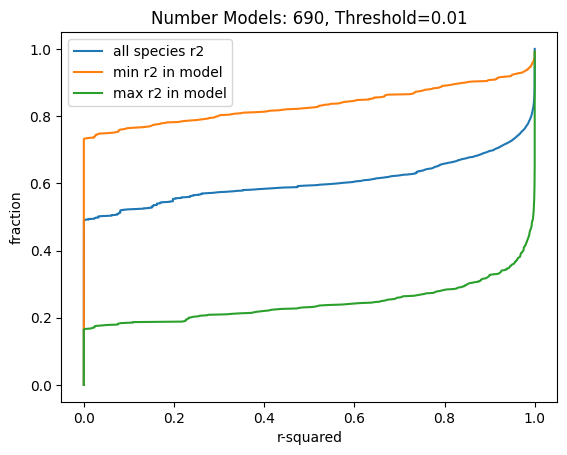

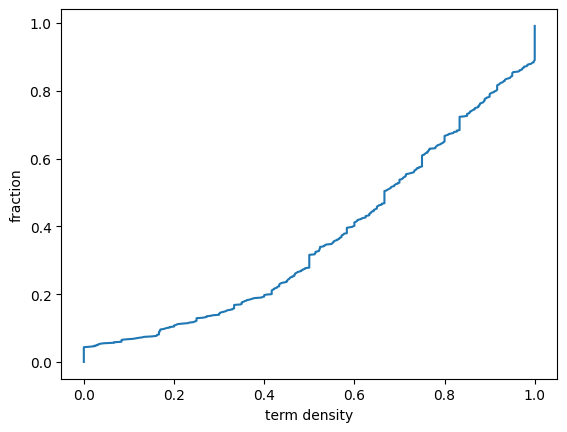

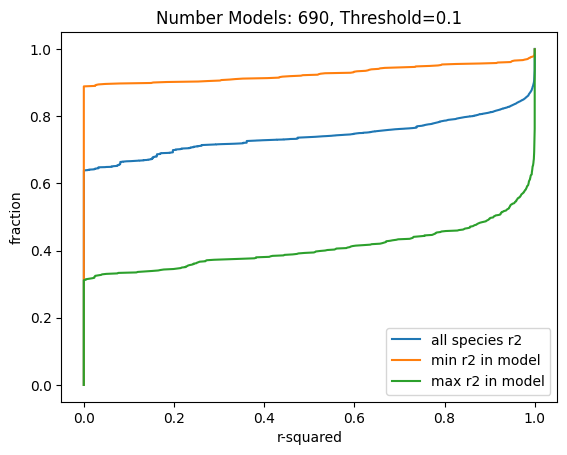

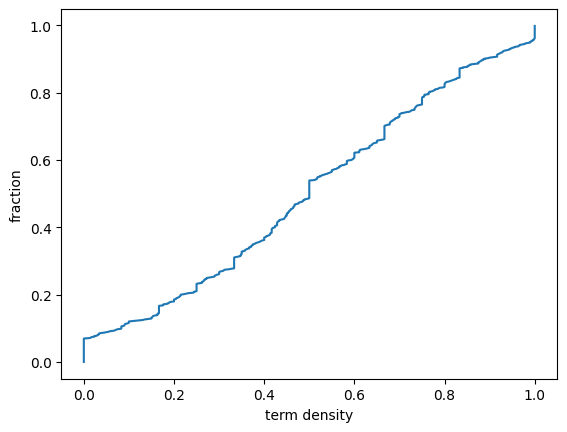

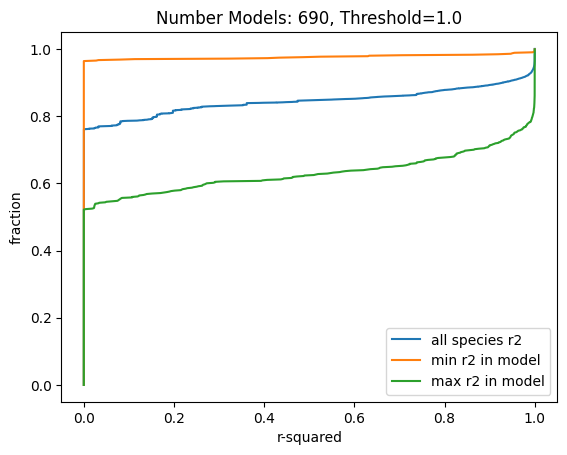

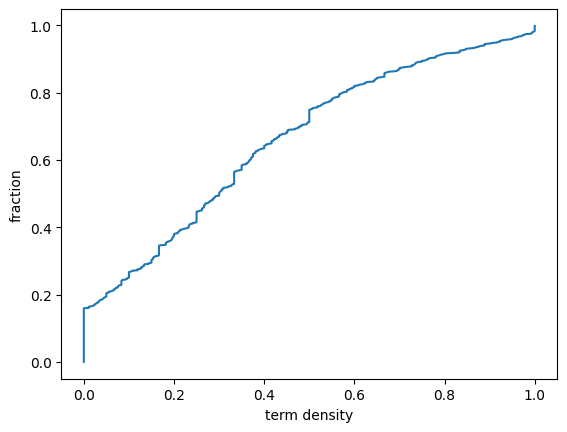

In [8]:
for threshold in ["0.001", "0.01", "0.1", "1.0"]:
    path = os.path.join(cn.DATA_DIR, "evaluate_monomial_models-" + threshold + ".csv")
    df = pd.read_csv(path)
    df["deg1_term_density"] = df["deg1_num_nonzero_term"]/(df["num_species"]*(df["num_species"] + 1))
    plt.figure()
    plotCDF(df, "deg1_values", title=f"Number Models: {len(df)}, Threshold={threshold}")
    plotCDF(df, "deg1_min")
    plotCDF(df, "deg1_max")
    _ = plt.legend(["all species r2", "min r2 in model", "max r2 in model"])
    _ = plt.title(f"Number Models: {len(df)}, Threshold={threshold}")
    plt.figure()
    plotValueCDF(df["deg1_term_density"].values, xlabel="term density")

# Perturbations

## BioModels 181

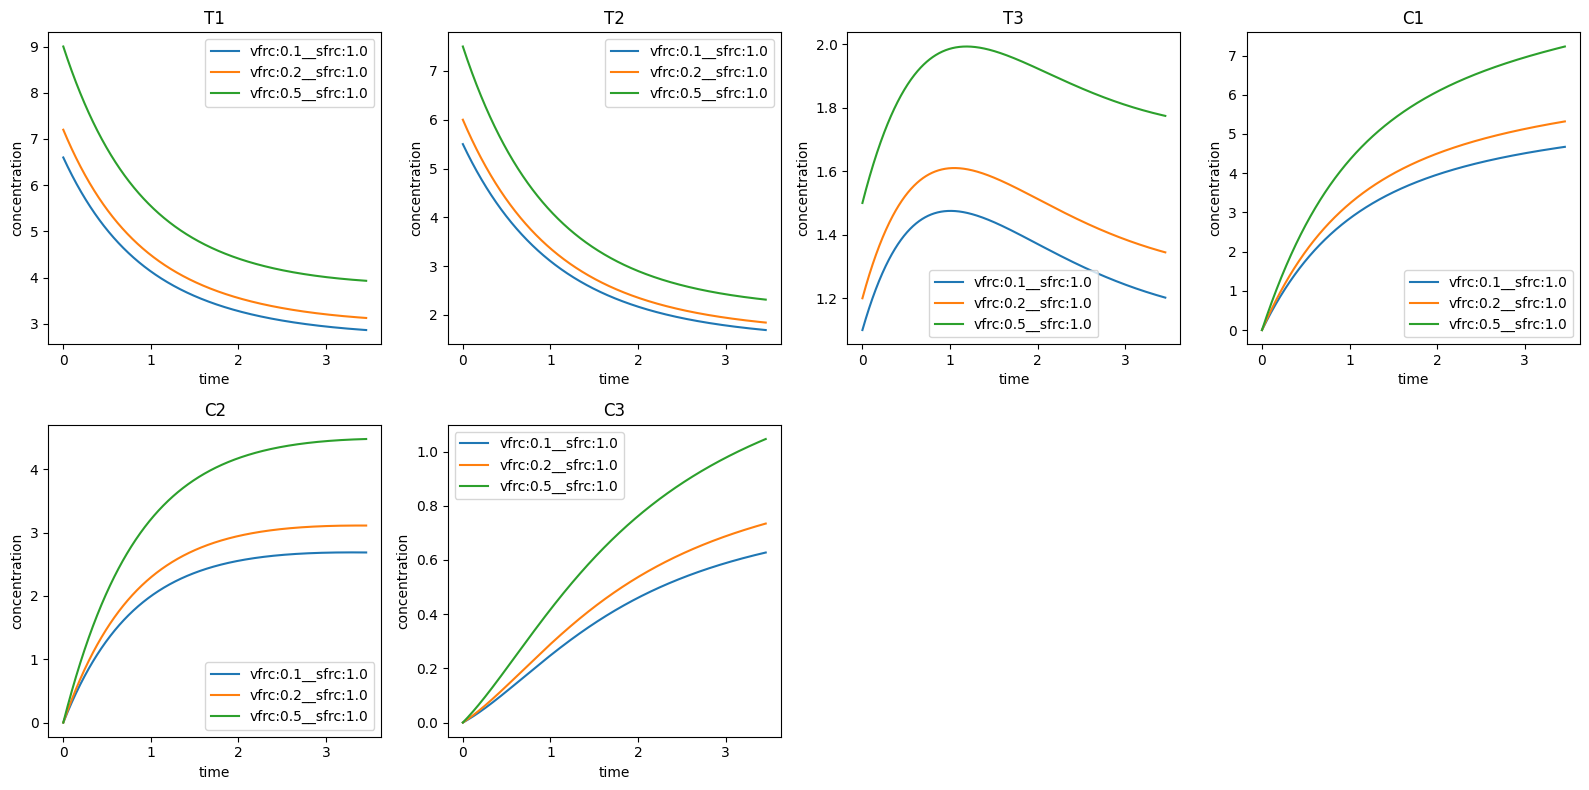

In [9]:
model = Model.makeBiomodel(model_num=181)
timecourse_df = Timecourse.makeTimecourses(
        model, num_point=1000,
        perturbation_value_fraction=[0.1, 0.2, 0.5],
        perturbation_species_fraction=[1.0],
        is_plot=True
        
    )
#timecourse_df


ds1/dt = 54.501 + -257.119 * s1 + -239.110 * at + -999.766 * s2 + 2671.475 * s3 + -80.760 * na + -313.154 * s4 + 537.840 * s5 + -6362.560 * s6 + 26566.881 * s6o
dat/dt = 584.317 + -470.522 * s1 + -491.998 * at + -1858.970 * s2 + 4740.896 * s3 + -1113.078 * na + -488.515 * s4 + 999.987 * s5 + -5694.635 * s6 + 40444.826 * s6o
ds2/dt = -4.093 + 257.069 * s1 + 239.121 * at + 990.041 * s2 + -2672.284 * s3 + 80.119 * na + 313.454 * s4 + -537.862 * s5 + 6363.242 * s6 + -26567.093 * s6o
ds3/dt = -185.075 + -3.149 * s1 + 1.942 * at + 13.332 * s2 + -42.058 * s3 + 292.691 * na + 0.511 * s4 + 8.019 * s5 + -1937.963 * s6 + 1888.031 * s6o
dna/dt = -65.674 + -1.110 * s1 + 2.591 * at + -3.567 * s2 + 24.648 * s3 + 73.409 * na + -0.035 * s4 + 9.424 * s5 + -1330.802 * s6 + 1855.885 * s6o
ds4/dt = -298.663 + -39.547 * s1 + -19.333 * at + -132.740 * s2 + 631.874 * s3 + 545.910 * na + -145.018 * s4 + 64.563 * s5 + -3481.181 * s6 + 8709.538 * s6o
ds5/dt = 438.844 + 41.506 * s1 + 16.860 * at + 136.994 * s2 +

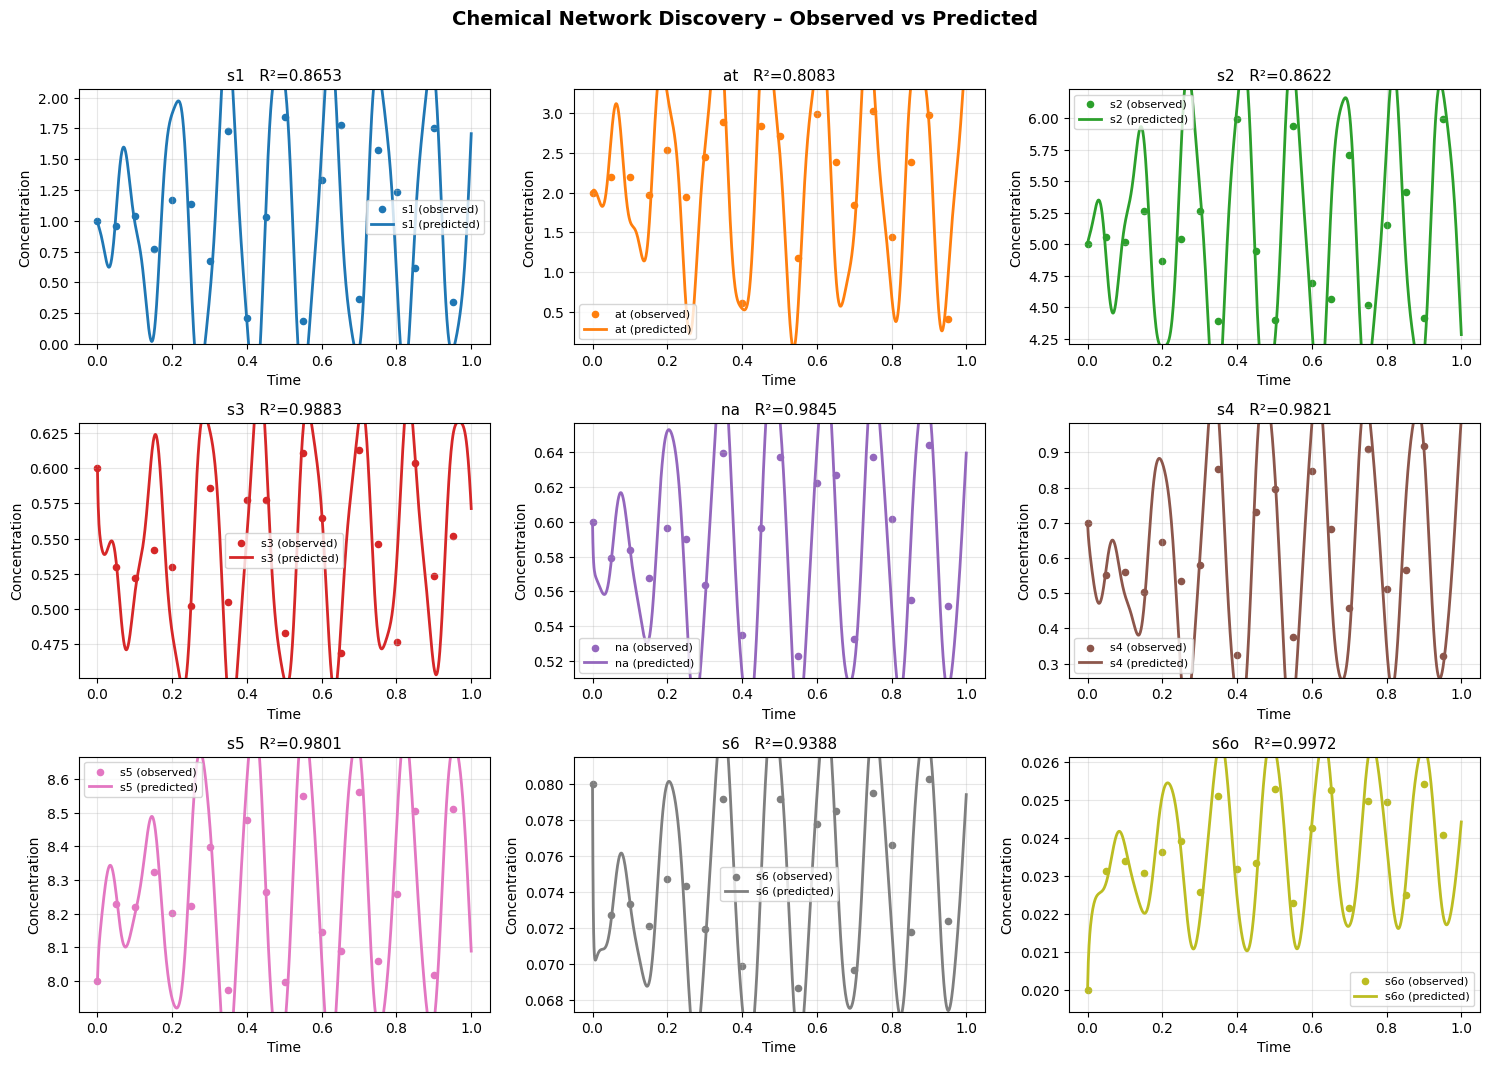

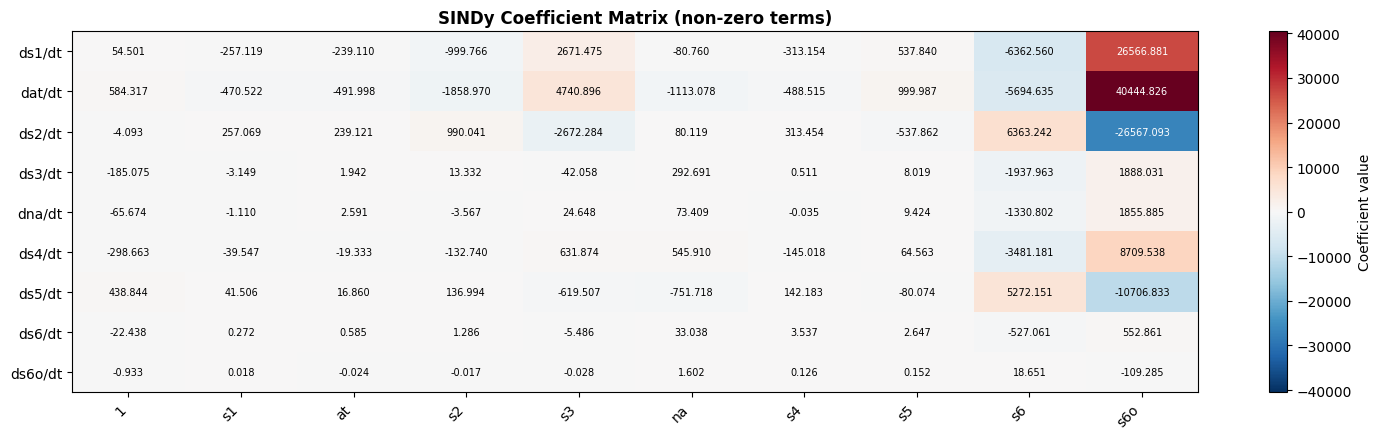

In [10]:
model_num =206
poly_degree = 1
threshold = 0.01
value_frc = 0.0
model = Model.makeBiomodel(model_num=model_num)
base_timecourse = Timecourse.makeTimecourses(
        model, num_point=1000,
        end_time=1,
        perturbation_value_fraction=[0.0],
        perturbation_species_fraction=[1.0],
        is_plot=False
        
    )[0]
change_timecourse = Timecourse.makeTimecourses(
        model, num_point=1000,
        end_time=1,
        perturbation_value_fraction=[value_frc],
        perturbation_species_fraction=[1.0],
        is_plot=False
        
    )[0]
sd = discoverNetwork(base_timecourse.timecourse_df,
        test_df=change_timecourse.timecourse_df,
        poly_degree=poly_degree, 
        threshold=threshold)

# Perturbation Analysis

In [11]:
## Single Model Analysis

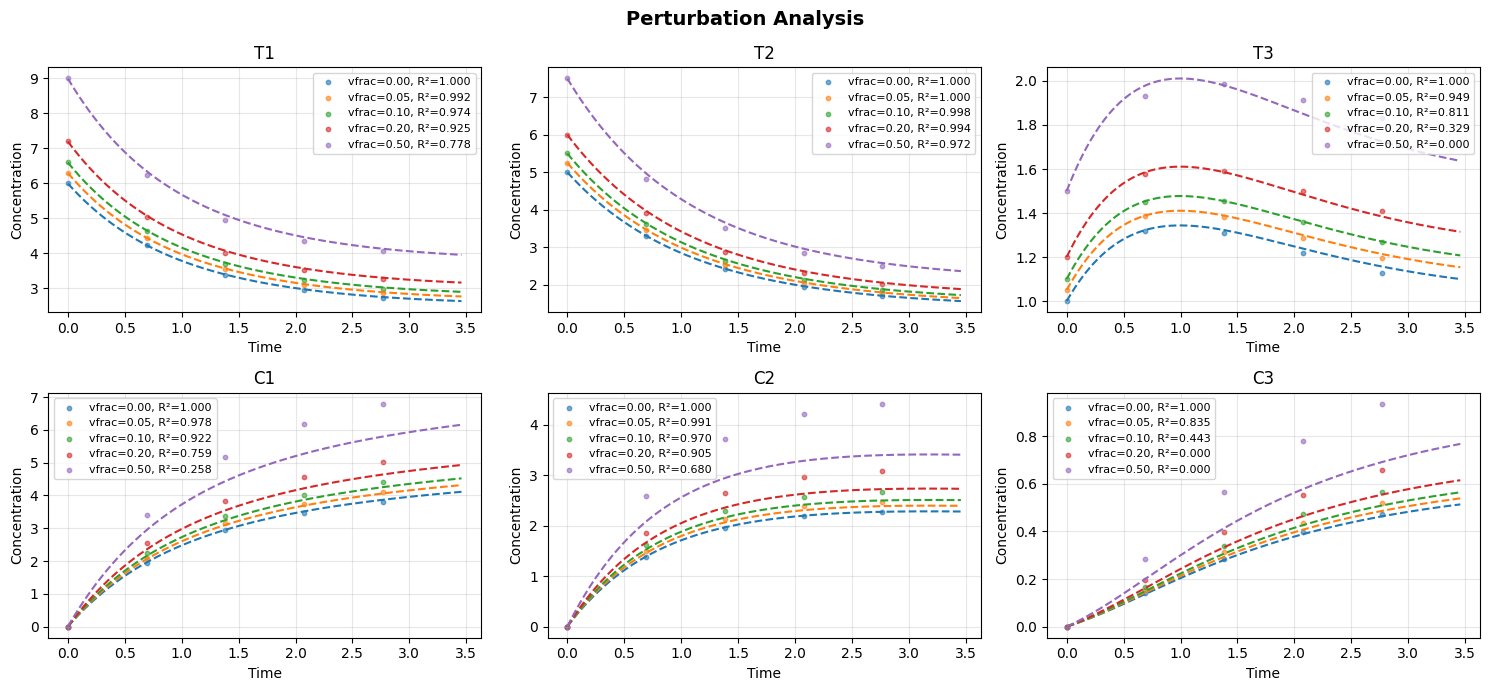

model_name    BIOMD0000000181
threshold                0.01
r2_0_min             0.999887
r2_0_med                  1.0
r2_0_max                  1.0
r2_+05_min           0.834729
r2_+05_med           0.984497
r2_+05_max           0.999583
r2_+10_min           0.442934
r2_+10_med           0.945734
r2_+10_max           0.998415
r2_+20_min                0.0
r2_+20_med            0.83168
r2_+20_max           0.994235
r2_+50_min                0.0
r2_+50_med           0.469199
r2_+50_max            0.97206
dtype: object

In [12]:
model_num =181
poly_degree = 1
threshold = 0.01
value_frc = 0.0
model = Model.makeBiomodel(model_num=model_num)
base_timecourse = Timecourse.makeTimecourses(
        model, num_point=1000,
        perturbation_value_fraction=[0.0],
        perturbation_species_fraction=[1.0],
        is_plot=False
        
    )[0]
change_timecourse = Timecourse.makeTimecourses(
        model, num_point=1000,
        perturbation_value_fraction=[value_frc],
        perturbation_species_fraction=[1.0],
        is_plot=False)[0]
training_df = base_timecourse.timecourse_df
test_df = change_timecourse.timecourse_df    
SystemDiscovery.analyzePerturbations(model, training_df, threshold=threshold,
                    perturbations=[0.0, 0.05, 0.1, 0.2, 0.5])

## Multiple Model Analysis

In [13]:
path = os.path.join(cn.DATA_DIR, "perturbation_studyi-0.01.csv")
PERTURBATION_DF = pd.read_csv(path)
PERTURBATION_DF.head()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/jlheller/home/Technical/repos/linearity_analysis/data/perturbation_studyi-0.01.csv'

In [ ]:
def plotPerturbationCDF(df: pd.DataFrame, r2_type:str = "med",
        ax=plt.gca(), is_plot: bool=True):
    """
    Plot CDFs for the changes present in the perturbation study.

    Args:
        df (pd.DataFrame): The DataFrame containing the perturbation data.
        r2_type (str, optional): _description_. Defaults to "med".
    """
    if not r2_type in ["med", "max", "min"]:
        raise ValueError("r2_type must be 'med', 'max', or 'min'")
    columns = [c for c in df.columns if r2_type in c]
    perturbation_column_dct = {c: c[3:-4] for c in columns}
    perturbation_value_dct = {perturbation_column_dct[c]: 
            df[c].sort_values().values for c in columns}
    length = len(df)
    frac_arr = np.arange(1, length + 1) / length
    for perturbation, values in perturbation_value_dct.items():
        if ax is None:
            plt.plot(values, frac_arr, label=perturbation) # type: ignore
        else:
            ax.plot(values, frac_arr, label=perturbation) # type: ignore
    ax.set_xlabel("r2")
    ax.set_ylabel("Cumulative Probability")
    ax.set_title("Perturbation CDF: " + r2_type)
    ax.legend()
    if is_plot:
        plt.show()

plotPerturbationCDF(PERTURBATION_DF, "min")

In [ ]:
def plotAllPerturbationCDFs(threshold: float=0.01, is_plot: bool=True):
    # Constrct the dataframe
    path = os.path.join(cn.DATA_DIR, "perturbation_study-" + str(threshold) + ".csv")
    df = pd.read_csv(path)
    # Create a 1 by 3 subplot for each r2 type
    if not is_plot:
        return
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for r2_type in ["min", "med", "max"]:
        plotPerturbationCDF(df, r2_type, ax=axes[["min", "med", "max"].index(r2_type)],
                is_plot=False)
        axes[["min", "med", "max"].index(r2_type)].set_title(f"R² {r2_type.capitalize()}")
    if not is_plot:
        return
    plt.show()

plotAllPerturbationCDFs(threshold=0.001)

In [ ]:
df = pd.read_csv(os.path.join(cn.DATA_DIR, "perturbation_study-0.001.csv"))
plotPerturbationCDF(df, "min")

plt.figure()
plotPerturbationCDF(df, "med")
plt.figure()
plotPerturbationCDF(df, "max")